<a href="https://colab.research.google.com/github/luciestrada/Lab-Biose-ales-V4-6_Lucianas-/blob/main/pr%C3%A1ctica4_biose%C3%B1ales_Lucianas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Luciana Acevedo Cadavid - Luciana Estrada García

**Práctica 4- Introducción a los biopotenciales y adquisición de señales ECG y EMG**

**RESUMEN**

La práctica consistió en el registro y análisis de señales bioeléctricas (ECG y EMG) utilizando electrodos y una placa Arduino UNO como sistema de adquisición. Posteriormente, las señales obtenidas fueron procesadas mediante Python.

Previo al análisis detallado, se realizó una identificación de la señal y de sus parámetros globales, logrando distinguir un offset y un pico anómalo en el instante inicial. A continuación, se procedió a la detección de los picos R empleando las librerías NeuroKit2 y py-ecg-detectors. Al comparar los diferentes algoritmos, se determinó que NeuroKit2 resultó ser el método más robusto y el que mejor detectó dichos picos. A partir de estos resultados, se calculó la cantidad y duración de los intervalos R-R y, consecuentemente, la variabilidad de la frecuencia cardíaca (HRV). Para una estimación completa de la HRV, se extrajeron diversas métricas utilizando la función get_time_domain_features.

Los resultados obtenidos a partir de la señal ECG indican que los valores son normales para una persona joven en estado de reposo, de acuerdo con las métricas extraídas (FC media ~85 lpm, SDNN ~45 ms, FC máx/mín ~98/71 lpm, entre otras).

En cuanto a la señal EMG, su procesamiento consistió en un centrado para eliminar el offset, seguido de una rectificación de onda completa para trasladar todas las oscilaciones al semiplano positivo. Finalmente, se calculó la envolvente aplicando un filtro de media móvil con una ventana de 100 ms, lo que permitió visualizar claramente la activación muscular a lo largo del tiempo.



**MARCO TEÓRICO**

**5.1 Realice un esquema donde se describan y expliquen las diferentes etapas del registro de biopotenciales, desde la generación de los potenciales de acción hasta su adquisición por el equipo.
Adicionalmente, describa a grandes rasgos los componentes de un equipo de adquisición.**

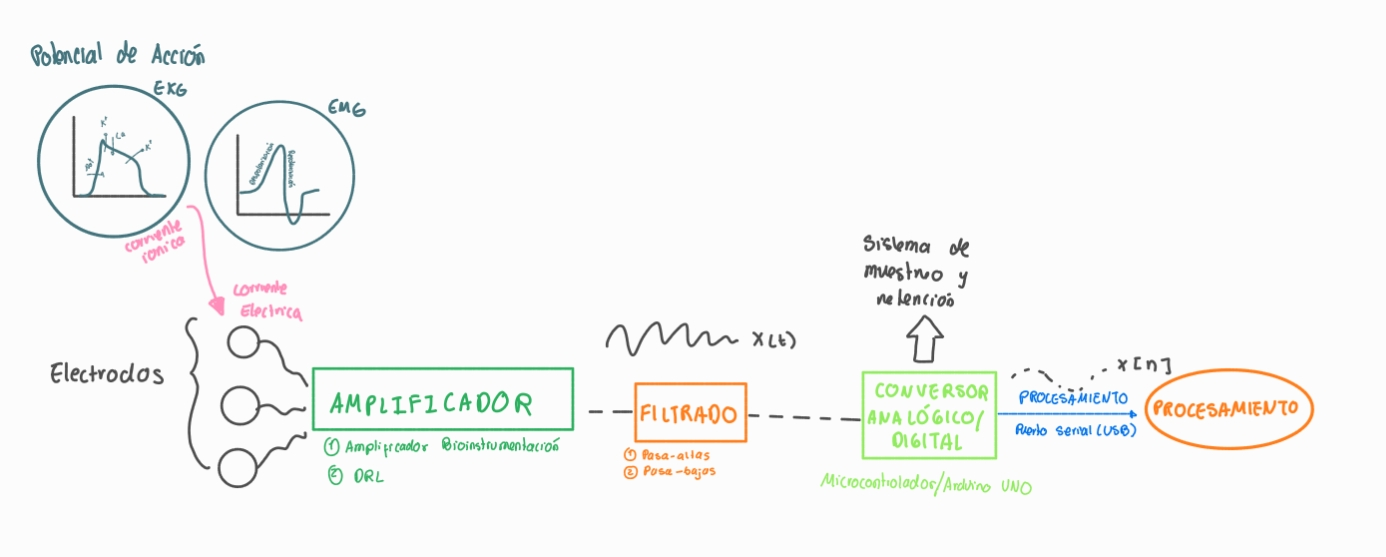

**Generación del potencial de acción**: Las células excitables del cuerpo (como los miocitos cardíacos o fibras musculares) mantienen una diferencia de carga eléctrica entre el interior y el exterior de su membrana celular. Cuando son estimuladas se abren canales iónicos de Na⁺/K⁺.  Este intercambio repentino invierte temporalmente la carga de la membrana, creando un impulso eléctrico conocido como potencial de acción.

**Electrodos (Ag/AgCl):**  Las corrientes iónicas viajan a través de tejidos que actúan como un medio conductor, desde el órgano generador hasta la superficie de la piel. Cuando se conduce esta electricidad los electrodos captan la corriente iónica extracelular y la convierten en un flujo de electrones (corriente eléctrica), actuando como transductores.

Una vez que la señal es captada por los electrodos, ingresa *al equipo de adquisición y etapa de acondicionamiento analógico.*

•**Amplificador de instrumentación:** El primer bloque de la etapa analógica es un amplificador de instrumentación junto con el circuito DRL (driven rigth leg), donde no solo multiplica el tamaño de la señal, sino que tiene un alta "Relación de Rechazo en Modo Común" (CMRR), lo que significa que elimina el ruido eléctrico.(Caggioli et al., 2007)

• **Filtrado**: Compuesto por un filtro Pasa-altas (elimina deriva de línea base < 0.5 Hz) , y un filtro pasa-bajas (limita el ancho de banda al de la señal de interés: 0.05–150 Hz para ECG; 20–500 Hz para EMG). Son usados principalmente para eliminar las posibles interferencias generados por la respiración del paciente, movimiento de los electrodos, o el ruido muscular involuntario.(Caggioli et al., 2007)

**Conversión analógico-digital (ADC):** Esta etapa está encargada principalmente y normalmente de un microcontrolador que está encargada de muestrear y digitalizar cada una de las señales de entrada mediante su módulo de conversión A/D de 8 bits, almacenando dichos datos en la memoria Compact Flash (CF) en forma continua, sector por sector.  Luego éstos pueden ser transmitidos haciendo uso del módulo UART (Universal Asynchronous Receiver-Transmitter) del mismo PIC hacia la PC. En nuestro caso se realizó la conversión por medio del ARDUINO UNO, y los valores digitales se envían por puerto serie (USB) al computador, donde con el código de Python los almacena en un archivo .txt para su posterior procesamiento. (Caggioli et al., 2007)

**5.2 Presente una tabla con las principales fuentes de ruido en el registro de biopotenciales.
Determine ¿Cuáles de estas fuentes de ruido son estáticas o variantes en el tiempo? Indique que
estrategias se utilizan para controlar o eliminar dicha fuente de ruido.**

| Fuente de ruido | ¿Estática o variante? | Origen / descripción | Estrategias de control |
|---|---|---|---|
| Interferencia de red (60 Hz) | Estática |Los campos electromagnéticos de la instalación eléctrica se acoplan de forma capacitiva al cuerpo y a los cables de los electrodos *(Boyer et al., 2023)*.| - Filtro digital estrecho de tope de banda, como un filtro muesca centrado a 50 Hz o 60 Hz.- Amplificador diferencial con alto CMRR + cable apantallado + electrodo DRL *(Boyer et al., 2023)*. |
| Ruido térmico (Johnson) | Estática |  Este ruido es intrínseco a cualquier resistencia,  y componentes del amplificador(sistema de amplificación); modelado como ruido blanco gaussiano con potencia uniforme en toda la banda*(Lyon et al., 2018)* *(Webster, 2009)*| Amplificadores de bajo ruido; minimizar impedancia de electrodo; promediado de señales. |
| Ruido de cuantización (ADC) | Estática (Depende exclusivamente del número de bits del conversor y del rango de referencia) | La diferencia entre el valor real y el valor digital más cercano es el error de cuantización. En esta práctica el ADC de 10 bits del Arduino UNO y referencia de 5V, se obtiene una resolución de ≈4.9 mV/bit. | ADC de mayor resolución (≥ 12 bits); ajustar VREF al rango dinámico real de la señal *(Webster, 2009)*|
| Artefacto de movimiento | **Variante** |Interfaz piel-electrodo: micro-desplazamientos cambian la impedancia de contacto, generando transitorios que se superponen a la señal *(Hancock et al., 2009)*. | Soporte del electrodo, gel conductor, adhesivo firme *(Cömert & Hyttinen, 2015)*.|
| Deriva de línea base (Baseline Wander) | **Variante** | Puede ser causada por respiración, variaciones en la impedancia del electrodo (suduración-temperatura)y movimiento excesivo del cuerpo. En general son cambios lentos (< 0.5 Hz) *(Wagner et al., 2009)*. |Filtro pasa-altas típico ajustado por debajo de 0.5 Hz, esto implica que siempre existe cierta superposición espectral entre la deriva y la señal real *(Luo et al., 2013)*. |
| Ruido de modo común | **Variante** | Señal presente simultáneamente en ambos electrodos causada por campos externos. Aparece por el desequilibrio de impedancias en la interfaz electrodo-cuerpo *(Lyon et al., 2018)*. | Amplificador diferencial con alto CMRR (> 80 dB);circuito DRL (Driven Right Leg)(Chen et al., 2020). |
| Crosstalk (interferencia EMG) | **Variante** |Actividad eléctrica de músculos vecinos captada por los electrodos del músculo de interés(La grasa subcutánea amplifica el crosstalk.)  *(Hancock et al., 2009)*. | El crosstalk no se reduce con filtrado temporal pasa-altas,  solo el filtrado espacial es efectivo. Por ende se puede reducir manipulando la distancia inter-electrodo (≤ 2 cm)*(Germer et al., 2021).* |


**5.3 Describa ¿Cuál es la problemática asociada al acoplamiento piel-electrodo? ¿Cuáles estrategias
se utilizan para mejorarla?**


La problemática principal se relaciona principalmente con la capa externa de la piel, que actúa como **aislante que generan resistencia, alta impedancia, y una gran susceptibilidad a interferencias**;  ocasionando atenuación de la señal, desbalance entre electrodos que degrada el CMRR del amplificador diferencial, y mayor susceptibilidad al ruido de modo común (60 Hz), que resulta finalmente en una medición de poca calidad *(Lyon et al., 2018)*.
 Adicionalmente, cambios en la humedad (sudor), temperatura y micro-desplazamientos de los electrodos alteran dinámicamente esta impedancia de contacto piel-electrodo *(Cömert & Hyttinen, 2015)*. Esta impedancia depende del material del electrodo y de la hidratación de la piel. En ausencia de electrolito o sudor, la alta impedancia hace muy difícil la adquisición de señales de alta calidad con electrodos secos que resulta en mala calidad de señal *(Goyal et al., 2022)*.
 A esto se le suma otro efecto que es el **potencial de offset** cuando dos electrodos tienen impedancias distintas por diferencias en la preparación de la piel o el gel aplicado, se genera un desbalance que degrada directamente el CMRR del amplificador diferencial *(Chen et al., 2020)*.

Para superar estas barreras y garantizar una lectura fiel, se aplican estrategias como: **la limpieza y abrasión suave de la piel** para remover células muertas, **el uso de adhesivo** que minimiza la variación dinámica de impedancia por movimiento, **la aplicación de geles conductores** que sirven como puente iónico, como el gel de cloruro de plata o pasta abrasiva reduce la impedancia de contacto a < 5 kΩ ; Sin embargo,  estudios han relevado que el ruido se origina principalmente en la interfaz piel-gel, no en el electrodo , cuando se aplica el gel conductor aplicado entre la piel y el electrodo metálico *(Murphy et al., 2021)*, por ende reduce la impedancia pero no soluciona el problema.
Otra estrategia es **el uso electrodos especializados** que estabilizan la conexión y maximizan la calidad de la señal, como  un electrodo activo con sistema de anclaje ajustable, que aumenta la tensión electrodo-piel y reduce el movimiento relativo, este logró registros de biopotencial con alta calidad sin preparación de la piel ni gel, con una impedancia DC de contacto promedio de 450 kΩ *(Valchinov & Pallikarakis, 2004)*, y finalmente por esta misma línea de electrodos la solución más común es el uso de electrodos de Ag/AgCl, ya que tienen baja polarización, y reducen el potencial de offset.
Estas técnicas ayudan a asegurar un mejor acoplamiento y, por ende, una medición de calidad más alta de las señales bioeléctricas


 **Además, responda ¿Por qué el acoplamiento piel-electrodo constituye
la etapa más crítica en el registro de señales de superficie (sEMG, EEG, ECG)?**

El acoplamiento piel-electrodo constituye la etapa más crítica en el registro de señales de superficie porque es el punto inicial en el proceso de adquisición, que corresponde a la transducción; si el primer eslabón de esta interfaz es deficiente, las señales biológicas se contaminan de ruido desde el origen y ninguna etapa de amplificación o filtrado posterior podrá recuperar la información original, ya que al recibir desde un comienzo estas señales eléctricas de muy baja amplitud, el ruido será del mismo orden la señal.

**5.4 Análisis de la Variabilidad de la frecuencia cardíaca (HRV)**

**1. Detectar los picos R utilizando la función de la librería NeuroKit y de  Detectors. ¿Cuál de los algoritmos detecta mejor los picos R?**

**2. Calcular la variabilidad de la frecuencia cardíaca (HRV) a partir de los picos R detectados.**

**3. Investigar e implementar las siguientefuncion de la librería hrvanalysis para extraer características de HRV en el dominio del tiempo: get_time_domain_features**

In [ ]:
#Es necesario realizar una instalacion de las librerias a usar

!pip install neurokit2 # Librería para procesamiento de señales fisiológicas --> Detección picos R, filtrado , y extracción caracteristicas fisiologicas
!pip install py-ecg-detectors # Librería para detección de picos R mediante algoritmos ECG (Pan-Tompkins, Hamilton,
#  Christov, Engzee-Engelse) para comparación.
!pip install hrv-analysis # Librería para cálculo de HRV

***Importaciones y parámetros globales***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Parámetros de adquisición
# En el código Arduino se usó delay(10)  → 10 ms por muestra → fs = 100 Hz
FS = 100        # Hz --> Frecuencia de muestreo
N  = 6000       # número total de muestras
T  = N / FS     # duración total en segundos (60 s)
t  = np.arange(N) / FS   # eje de tiempo en segundos

#Según el teorema de Nyquist, fs = 100 Hz permite representar
# señales de hasta 50 Hz sin aliasing.

print(f'Duración: {T:.0f} s | fs: {FS} Hz | Muestras: {N}')

Duración: 60 s | fs: 100 Hz | Muestras: 6000


***Cargamos datos***

In [ ]:
from google.colab import files
uploaded = files.upload()   # Subir ecgdatos.txt y emgdatos.txt

Saving ecgdatos.txt to ecgdatos (4).txt
Saving emgdatos.txt to emgdatos (4).txt


**Imagen desde la serial ARDUIN UNO**:
Podemos observar que tiene un offset, y tiene un pico en el instante 0
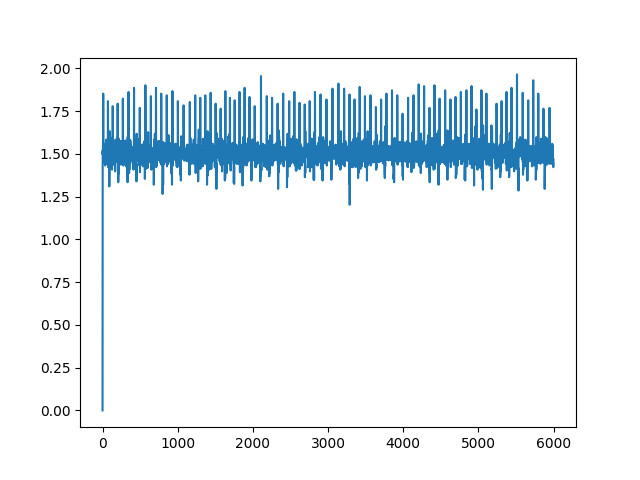

  ECG → min: 1.202 V  max: 1.965 V
  EMG → min: 1.075 V  max: 1.691 V


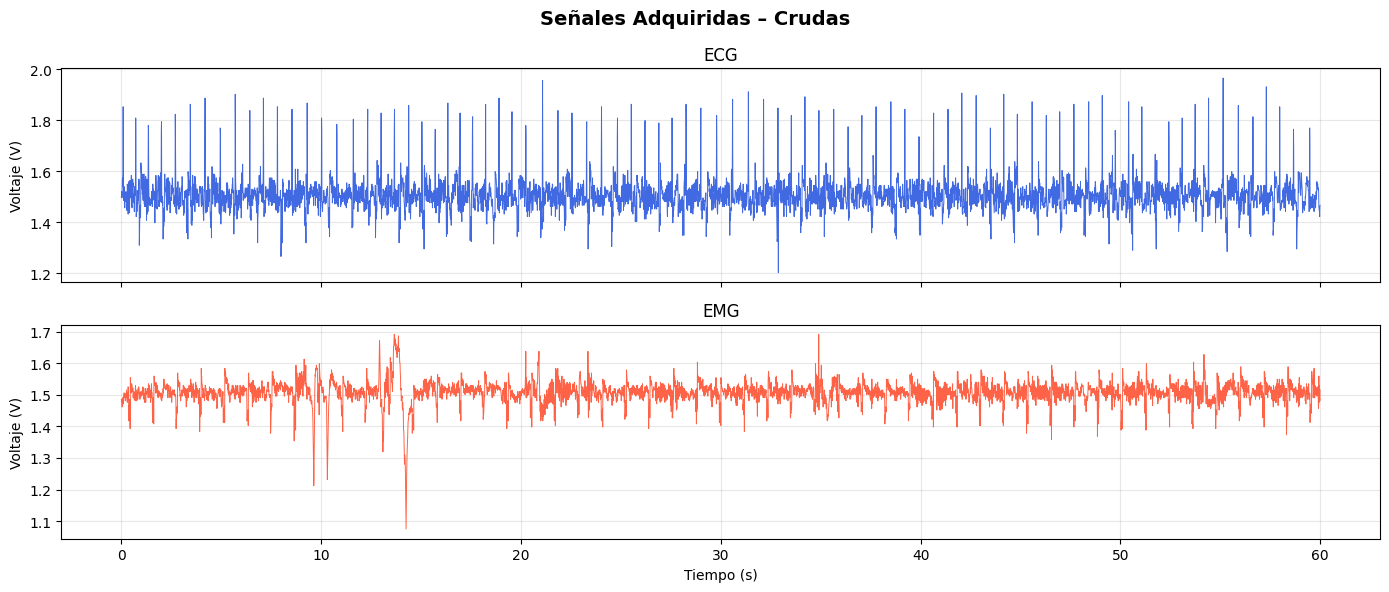

In [ ]:
ecg = np.loadtxt('ecgdatos.txt')
emg = np.loadtxt('emgdatos.txt')

# Al ver la gráfica obtenida por serial es necesario Eliminar el primer valor de la muestra= 0,
# Ya que al inicio hay un pico distornisnado , porque el puerto serie no está estabilizado al inicio
ecg[0] = ecg[1]
emg[0] = emg[1]

print(f'  ECG → min: {ecg.min():.3f} V  max: {ecg.max():.3f} V')
print(f'  EMG → min: {emg.min():.3f} V  max: {emg.max():.3f} V')

# ── Figura 1: Señales crudas ───────────────────────────────────────────
#Figuras tal cual y salen en el ADC de arduino

fig1, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig1.suptitle('Señales Adquiridas – Crudas', fontsize=14, fontweight='bold')

axes[0].plot(t, ecg, color='royalblue', lw=0.7)
axes[0].set_ylabel('Voltaje (V)')
axes[0].set_title('ECG')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, emg, color='tomato', lw=0.7)
axes[1].set_ylabel('Voltaje (V)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_title('EMG')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las señal presentan un OFFSET aproximadamente de 1.3 -1.7V

---
***a. Detección de picos R con NeuroKit2 y py-ecg-detectors***

El pico R es el punto de mayor amplitud del complejo QRS,que corresponde a la despolarización ventricular. Su detección
precisa es el primer paso para calcular HRV, FC y otros indicadores cardíacos.

**----- Algortimos que se comparan -----**

1. NeuroKit2: Al usar las funciones de esta libreria internamente aplica filtrado adaptativo + validación morfológica del QRS.Es el más robusto para señales de baja calidad como las adquiridas con Arduino.

2. Hamilton (1986):Basado en umbral adaptativo sobre la derivada de la señal.Robusto y rápido. Mejora significativamente la lógica de los umbrales de detección y añade reglas específicas para descartar los picos de la "onda T".

3. Christov (2004):Algoritmo pensado para eliminar el ruido electromiográfico. Usa combinación de criterios de pendiente, amplitud y anchura.Moderadamente robusto a ruido de cuantización.

4. Engzee-Engelse (1979):Diseñado para fs ≥ 250 Hz. A fs=100 Hz tiene pocos puntos
por QRS para estimar derivadas, lo que explica que no detecte picos en esta señal (limitación conocida del algoritmo).

5. Pan-Tompkins (1985): Algoritmo clásico y referencia en la literatura. Aplica filtro pasa-banda + derivada + elevación al cuadrado + ventana.


In [ ]:
import neurokit2 as nk
from ecgdetectors import Detectors

# ── NeuroKit2 ─────────────────────────────────────────────────────────────────
ecg_procesado, info_nk = nk.ecg_process(ecg, sampling_rate=FS)
picos_R_nk = info_nk['ECG_R_Peaks']
ecg_limpio  = ecg_procesado['ECG_Clean']
print(f'NeuroKit2 detectó {len(picos_R_nk)} picos R')

# ── py-ecg-detectors ──────────────────────────────────────────────────────────
detectors = Detectors(FS)

def detectar(nombre, fn):
    try:
        picos = np.array(fn(ecg))
        print(f'  {nombre:<22}: {len(picos)} picos R')
        return picos
    except Exception as e:
        print(f'  {nombre:<22}: Error – {e}')
        return np.array([])

print()
r_hamilton     = detectar('Hamilton',       detectors.hamilton_detector)
r_christov     = detectar('Christov',       detectors.christov_detector)
r_engzee       = detectar('Engzee-Engelse', detectors.engzee_detector)
r_pan_tompkins = detectar('Pan-Tompkins',   detectors.pan_tompkins_detector)

NeuroKit2 detectó 84 picos R

  Hamilton              : 87 picos R
  Christov              : 197 picos R
  Engzee-Engelse        : Error – Digital filter critical frequencies must be 0 < Wn < 1
  Pan-Tompkins          : 87 picos R


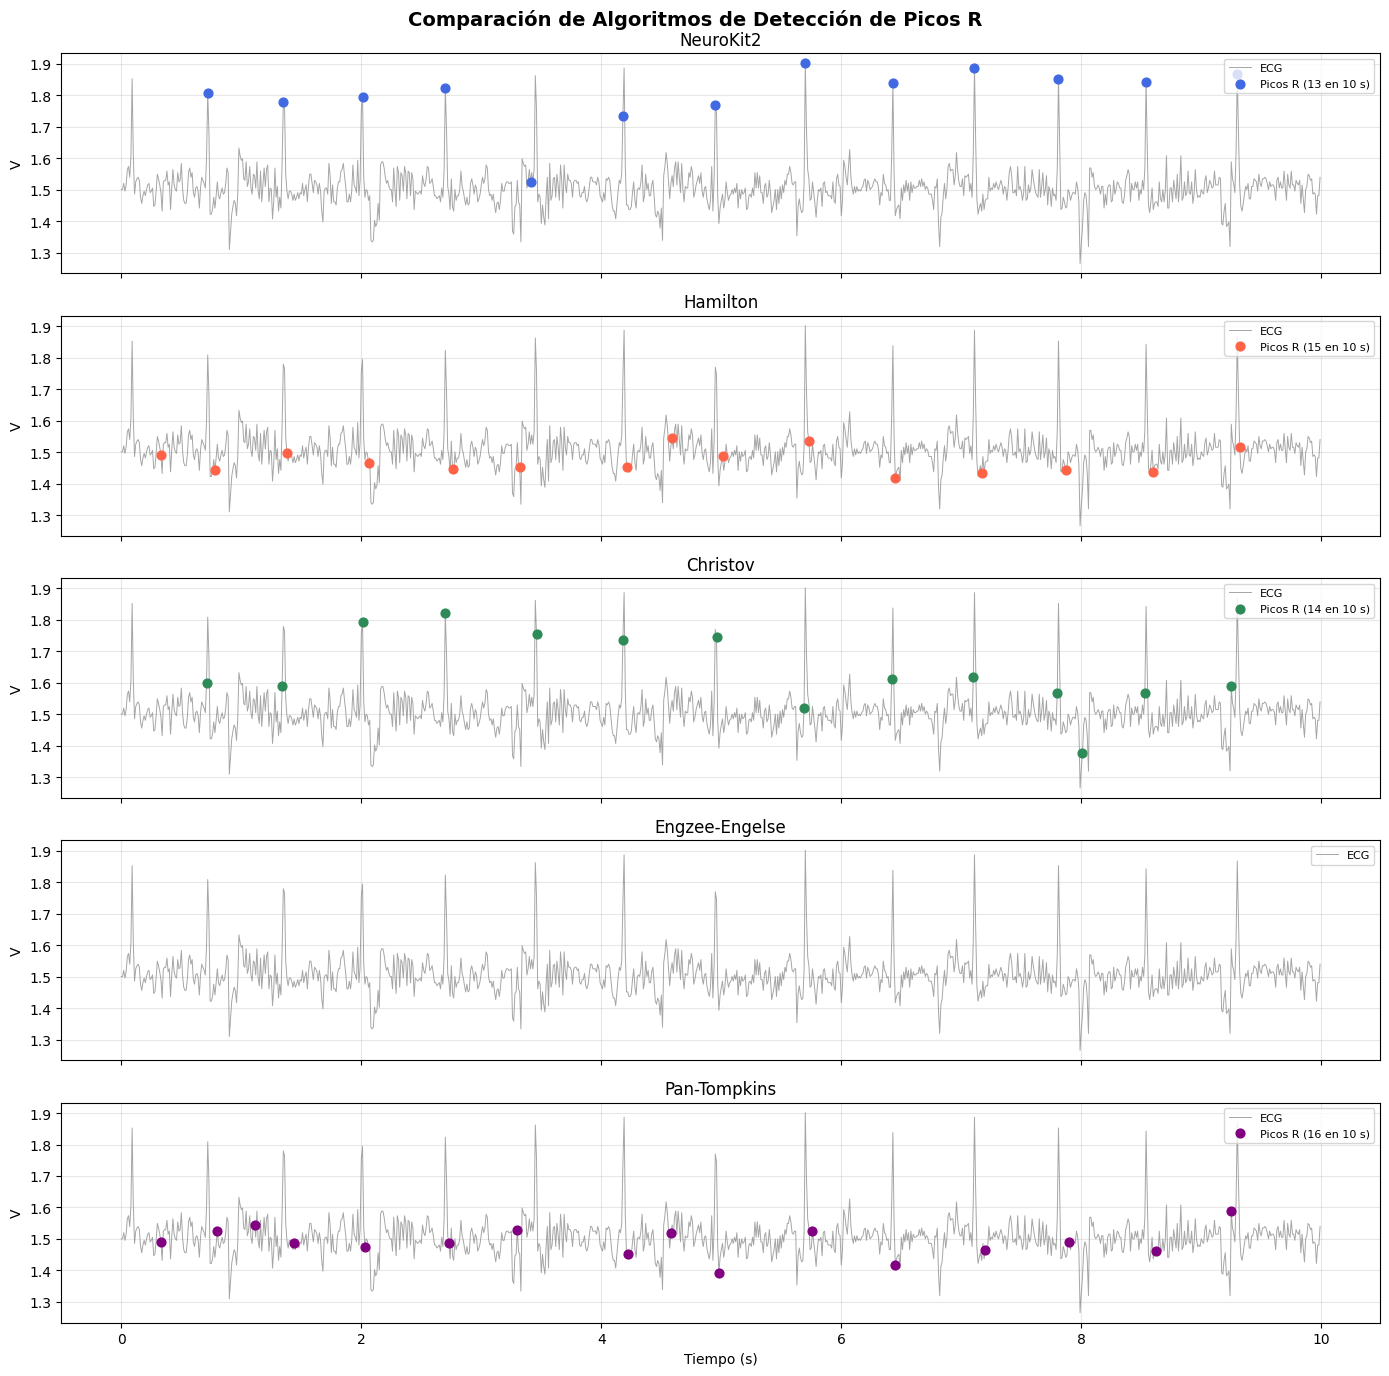

✓ Figura 2 guardada


In [ ]:
#NeuroKit2, es la referencia . Todos se comparan respecto a NeuroKit

# ── Figura 2: Comparación de detectores ──────────────────────────────────────
## Se grafica un segmento de 10 segundos para que los picos R sean visibles individualmente

fig2, axes2 = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
fig2.suptitle('Comparación de Algoritmos de Detección de Picos R', fontsize=14, fontweight='bold')

seg   = slice(0, 10 * FS)   #segmento: primeras 1000 muestras = 10 s
t_seg = t[seg]

detectores_lista = [
    ('NeuroKit2',      picos_R_nk,    'royalblue'),
    ('Hamilton',       r_hamilton,    'tomato'),
    ('Christov',       r_christov,    'seagreen'),
    ('Engzee-Engelse', r_engzee,      'darkorange'),
    ('Pan-Tompkins',   r_pan_tompkins,'purple'),
]

for ax, (nombre, picos, color) in zip(axes2, detectores_lista):
   # Señal ECG cruda
    ax.plot(t_seg, ecg[seg], color='gray', lw=0.7, alpha=0.7, label='ECG')

    # Filtrar picos que caen dentro del segmento de 10 s
    picos_seg = picos[(picos >= 0) & (picos < 10 * FS)] if len(picos) > 0 else []
    if len(picos_seg) > 0:
      # Graficamos punto en la amplitud real de la señal en cada pico detectado
        ax.scatter(np.array(picos_seg) / FS, ecg[picos_seg],
                   color=color, zorder=5, s=40,
                   label=f'Picos R ({len(picos_seg)} en 10 s)')
    ax.set_ylabel('V')
    ax.set_title(nombre)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes2[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.savefig('fig2_deteccion_picos_R.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura 2 guardada')

#Los puntos de colores indican dónde cada algoritmo ubicó el pico R.

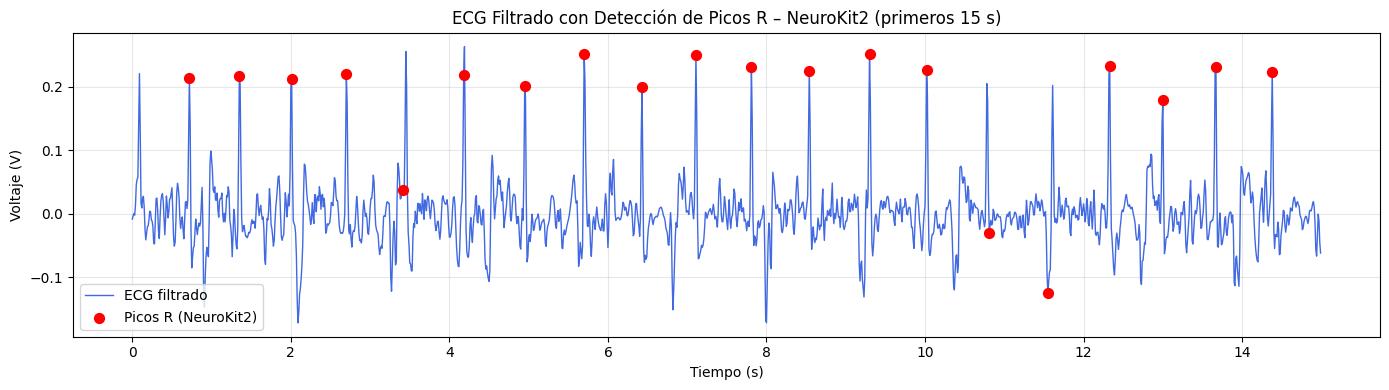

✓ Figura 5 guardada

───────────────────────────────────────────────────────
 Comparación de detectores de picos R
───────────────────────────────────────────────────────
 Algoritmo               Picos R
───────────────────────────────────────────────────────
 NeuroKit2                    84
 Hamilton                     87
 Christov                    197
 Engzee-Engelse                0
 Pan-Tompkins                 87


In [ ]:
# ── Figura 5: ECG filtrado con picos R ───────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(14, 4))
seg2 = slice(0, 15 * FS)   # primeros 15 segundos

ax5.plot(t[seg2], ecg_limpio[seg2], color='royalblue', lw=1, label='ECG filtrado')

# Marcar solo los picos R dentro de los primeros 15 s
picos_seg2 = picos_R_nk[(picos_R_nk >= 0) & (picos_R_nk < 15 * FS)]
ax5.scatter(np.array(picos_seg2) / FS, ecg_limpio[picos_seg2],
            color='red', zorder=5, s=50, label='Picos R (NeuroKit2)')
ax5.set_xlabel('Tiempo (s)')
ax5.set_ylabel('Voltaje (V)')
ax5.set_title('ECG Filtrado con Detección de Picos R – NeuroKit2 (primeros 15 s)')
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_ecg_procesado.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura 5 guardada')

# ── Comparación de algoritmos ─────────────────────────────────────────────────
print()
print('─'*55)
print(' Comparación de detectores de picos R')
print('─'*55)
print(f' {"Algoritmo":<22} {"Picos R":>8}')
print('─'*55)
for nombre, picos, _ in detectores_lista:
    print(f' {nombre:<22} {len(picos):>8}')


 NeuroKit2 es generalmente el más robusto porque aplica una versión optimizada de Pan-Tompkins con filtrado adaptativo, corrección de artefactos y validación morfológica del QRS.

Al observar las gráficas, podemos encontrar que el detector de **Engzee-Engelse** falla frecuentemente en señales de baja calidad como las del Arduin, ya que no detecta ningún pico.

El algoritmo de **Engzee-Engelse** fue desarrollado originalmente para señales con frecuencias de muestreo de 250 Hz o más. Nuestra señal tiene solo 100 Hz (fs=100 con delay(10) en Arduino), lo que le da muy pocos puntos por cada segmento QRS para que el algoritmo pueda detectar correctamente la morfología.





NeuroKit2 fue el que mejor detectó los picos R(84 picos) , Hamilton y Pan-Tompkins obtuvieron resultados muy similares entre sí , y solo 3 detecciones adcionales respecto a la referencia, probablmente falsos positivos por el ruido del ADC. Christov sobre-detectó 197 picos, al confudir oscilaciones de ruido de cuantización con eventos de QRS reales.


---
Se usa el ECG filtrado por NeuroKit2 (no el crudo) para visualizar mejor la morfología P-QRS-T y confirmar que los picos R detectados corresponden al punto de máxima amplitud del complejo QRS, no a artefactos.

***c. Cálculo de la Variabilidad de la Frecuencia Cardíaca (HRV)***

Intervalos R-R calculados : 83
R-R medio                 : 707.8 ms
FC estimada               : 84.8 lpm
R-R mín                   : 610.0 ms
R-R máx                   : 840.0 ms


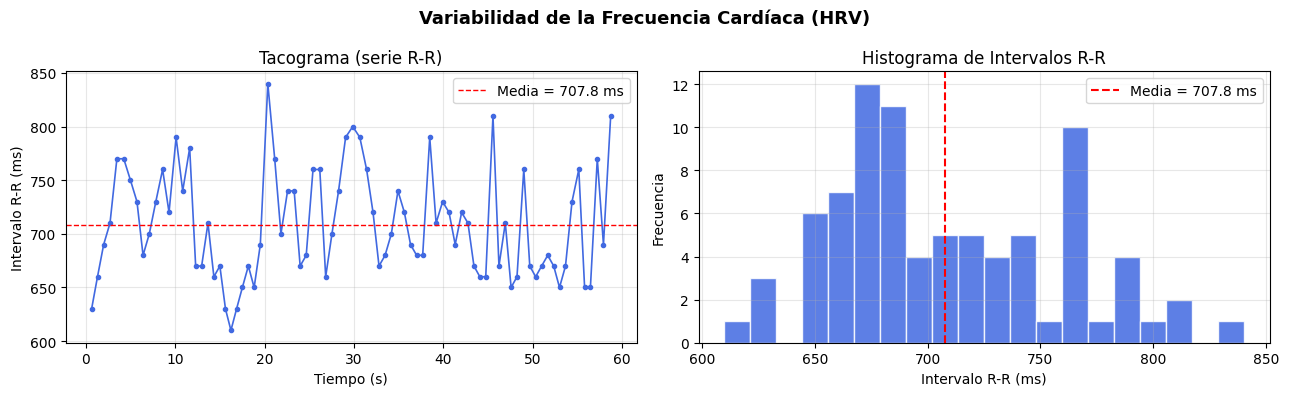

✓ Figura 3 guardada


In [ ]:
# Intervalos R-R en milisegundos (usando NeuroKit2 como referencia)
# Se usan los picos de NeuroKit2 por ser los más confiables.

rr_ms = np.diff(picos_R_nk) / FS * 1000 # intervalos R-R en milisegundos


print(f'Intervalos R-R calculados : {len(rr_ms)}')
print(f'R-R medio                 : {np.mean(rr_ms):.1f} ms')
print(f'  R-R medio (mean NNI)   : {np.mean(rr_ms):.1f} ms')
print(f'R-R mín                   : {np.min(rr_ms):.1f} ms')
print(f'R-R máx                   : {np.max(rr_ms):.1f} ms')
print(f'FC estimada               : {60000 / np.mean(rr_ms):.1f} lpm')

#SEGUN LA LITERATUEA
# Un R-R medio de ~800 ms corresponde a ~75 lpm (reposo normal)
# Valores fuera del rango 300–2000 ms indican artefactos o latidos ectópicos que deberían filtrarse antes del análisis HRV.


# ── Figura 3: Tacograma e histograma ─────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))
fig3.suptitle('Variabilidad de la Frecuencia Cardíaca (HRV)', fontsize=13, fontweight='bold')

t_rr = np.cumsum(rr_ms) / 1000   # tiempo acumulado en segundos

axes3[0].plot(t_rr, rr_ms, color='royalblue', lw=1.2, marker='o', ms=3)
axes3[0].set_xlabel('Tiempo (s)')
axes3[0].set_ylabel('Intervalo R-R (ms)')
axes3[0].set_title('Tacograma (serie R-R)')
axes3[0].axhline(np.mean(rr_ms), color='red', linestyle='--', lw=1,
                 label=f'Media = {np.mean(rr_ms):.1f} ms')
axes3[0].legend()
axes3[0].grid(True, alpha=0.3)

axes3[1].hist(rr_ms, bins=20, color='royalblue', edgecolor='white', alpha=0.85)
axes3[1].set_xlabel('Intervalo R-R (ms)')
axes3[1].set_ylabel('Frecuencia')
axes3[1].set_title('Histograma de Intervalos R-R')
axes3[1].axvline(np.mean(rr_ms), color='red', linestyle='--', lw=1.5,
                 label=f'Media = {np.mean(rr_ms):.1f} ms')
axes3[1].legend()
axes3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_hrv.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura 3 guardada')

A partir de los 84 picos R detectados se obtuvieron 83 intervalos R-R con una duración media de 707.8 ms, equivalente a una frecuencia cardíaca de aproximadamente 85 lpm.( Valor normal para una persona en reposo, que está dentro del rango normal(60-100 lpm))

 Los intervalos variaron entre 610 y 840 ms, un rango de 230 ms .El cual es fisiologicamente amplio, esto puede ser explicable porque durante la respiración normal, el corazón acelera ligeramente al inhalar y desacelera al exhalar, fenómeno conocido como arritmia sinusal respiratoria. El cual es un marcador de buena salud cardiovascular.

---
### c– **get_time_domain_features**

La librería **hrv-analysis** no es compatible  con Python ≥ 3.12 , y Google Colab actualmente ejecuta  Python 3.12. Por este motivo, **se implementa get_time_domain_features() de forma manual**,   replicando exactamente las fórmulas matemáticas y los nombres de claves del código fuente  original (DESDE: github.com/Aura-healthcare/hrv-analysis/blob/master/hrvanalysis/extract_features.py).  

*El resultado es idéntico al que produciría la librería.*

***El HRV (variabilidad de la frecuencia cardíaca) mide las fluctuaciones en el tiempo entre los latidos del corazón y refleja la salud del sistema nervioso autónomo y la capacidad de adaptación al estrés.***

In [ ]:


def get_time_domain_features(nn_intervals):
    """
    Parámetros
    ----------
    nn_intervals : array-like
        Intervalos R-R consecutivos en milisegundos.

    Retorna
    -------
    dict con las siguientes métricas (mismos keys que hrvanalysis):
        mean_nni, sdnn, sdsd, nni_50, pnni_50, nni_20, pnni_20,
        rmssd, median_nni, range_nni, cvsd, cvnni,
        mean_hr, max_hr, min_hr, std_hr
    """

    nn       = np.array(nn_intervals, dtype=float)
    diff_nn  = np.diff(nn)

    # ── Estadísticas sobre intervalos NN ───────────────────────────────

    mean_nni   = np.mean(nn)
    sdnn       = np.std(nn, ddof=1)          # desviación estándar (ddof=1),  la desviación estándar de los intervalos R-R del electrocardiograma
    sdsd       = np.std(diff_nn, ddof=1)     # SD de diferencias sucesivas
    rmssd      = np.sqrt(np.mean(diff_nn**2))# raíz cuadrática media de diferencias-->un indicador clave de la actividad del sistema nervioso parasimpático
    median_nni = np.median(nn)
    range_nni  = np.max(nn) - np.min(nn)

    # ── Porcentajes de diferencias > umbral ───────────────────────────────────
    nni_50  = int(np.sum(np.abs(diff_nn) > 50))
    pnni_50 = 100.0 * nni_50 / len(diff_nn)
    nni_20  = int(np.sum(np.abs(diff_nn) > 20))
    pnni_20 = 100.0 * nni_20 / len(diff_nn)

    # ── Coeficientes de variación ─────────────────────────────────────────────
    cvsd  = rmssd    / mean_nni   # CV basado en RMSSD
    cvnni = sdnn     / mean_nni   # CV basado en SDNN

    # ── Estadísticas sobre frecuencia cardíaca instantánea ────────────────────
    # 1. Calculamos las métricas que faltaban manualmente
    # 60,000 ms = 60 segundos
    # FC (lpm) = 60,000 / Intervalo (ms)

    hr     = 60000.0 / nn         # FC instantánea en lpm
    mean_hr = np.mean(hr)
    max_hr  = np.max(hr) # Intervalo más corto = FC más alta
    min_hr  = np.min(hr)# Intervalo más largo = FC más baja
    std_hr  = np.std(hr, ddof=1)

    return {
        'mean_nni':   mean_nni,
        'sdnn':       sdnn,
        'sdsd':       sdsd,
        'nni_50':     nni_50,
        'pnni_50':    pnni_50,
        'nni_20':     nni_20,
        'pnni_20':    pnni_20,
        'rmssd':      rmssd,
        'median_nni': median_nni,
        'range_nni':  range_nni,
        'cvsd':       cvsd,
        'cvnni':      cvnni,
        'mean_hr':    mean_hr,
        'max_hr':     max_hr,
        'min_hr':     min_hr,
        'std_hr':     std_hr,
    }

# ── Aplicar sobre los intervalos R-R del ECG adquirido ────────────────────────
time_features = get_time_domain_features(rr_ms)

print('═'*58)
print('  CARACTERÍSTICAS HRV – DOMINIO DEL TIEMPO')
print('  (get_time_domain_features — hrvanalysis)')
print('═'*58)

etiquetas = {
    'mean_nni':   ('Media R-R (Mean NNI)',         'ms'), #promedio del tiempo entre latidos
    'sdnn':       ('SDNN',                         'ms'), #desviación estándar de todos los R-R
    'sdsd':       ('SDSD',                         'ms'), #desviación estándar de las diferencias entre R-R consecutivos
    'rmssd':      ('RMSSD',                        'ms'),
    'median_nni': ('Mediana R-R (Median NNI)',     'ms'), # Es el promedio del tiempo entre latidos --> de acá se deriva la FC media
    'range_nni':  ('Rango R-R (Range NNI)',        'ms'),#Mide la amplitud total de variación
    'nni_50':     ('NNI50 (conteo)',               ''),# Número absoluto de pares de R-R consecutivos que difieren en más de 50 ms
    'pnni_50':    ('pNNI50',                       '%'),#Conteo expresado como porcentaje del total de diferencias
    'nni_20':     ('NNI20 (conteo)',               ''),# LO MISMO QUE EL ANTERIOR PERO CON UMBRAL DE 20 ms
    'pnni_20':    ('pNNI20',                       '%'),
    'cvsd':       ('CVSD (RMSSD/Mean)',            ''),#  RMSSD dividido entre la media R-R -->Normaliza el RMSSD por la FC
    'cvnni':      ('CVNNI (SDNN/Mean)',            ''),#SDNN dividido entre la media R-R--> variabilidad global



    'mean_hr':    ('FC media',                     'lpm'),
    'max_hr':     ('FC máxima',                    'lpm'),
    'min_hr':     ('FC mínima',                    'lpm'),
    'std_hr':     ('Desv. estándar FC',            'lpm'),
}

for key, (nombre, unidad) in etiquetas.items():
    val = time_features[key]
    if isinstance(val, float):
        print(f'  {nombre:<35} {val:>10.4f}   {unidad}')
    else:
        print(f'  {nombre:<35} {val:>10}   {unidad}')
print('═'*58)

══════════════════════════════════════════════════════════
  CARACTERÍSTICAS HRV – DOMINIO DEL TIEMPO
  (get_time_domain_features — hrvanalysis)
══════════════════════════════════════════════════════════
  Media R-R (Mean NNI)                  707.8313   ms
  SDNN                                   50.3657   ms
  SDSD                                   55.9767   ms
  RMSSD                                  55.6776   ms
  Mediana R-R (Median NNI)              700.0000   ms
  Rango R-R (Range NNI)                 230.0000   ms
  NNI50 (conteo)                              21   
  pNNI50                                 25.6098   %
  NNI20 (conteo)                              47   
  pNNI20                                 57.3171   %
  CVSD (RMSSD/Mean)                       0.0787   
  CVNNI (SDNN/Mean)                       0.0712   
  FC media                               85.1808   lpm
  FC máxima                              98.3607   lpm
  FC mínima                              71.4286

Los resultados muestran un perfil cardiovascular completamente normal para una persona joven en reposo. Con una variabilidad global adecuada.

Los tres indicadores parasimpáticos (RMSSD, pNNI50 y el rango R-R de 230 ms) apuntan en la misma dirección: el corazón está respondiendo normalmente al ciclo respiratorio mediante arritmia sinusal respiratoria.

***RESUMEN FINAL***

In [ ]:
# Imprimimos el resumen final
# Usamos las variables calculadas arriba
# Usamos las llaves del diccionario

print('═'*55)
print('   RESUMEN FINAL')
print('═'*55)
print(f'   Duración señal          : {T:.0f} s')
print(f'   Frecuencia de muestreo  : {FS} Hz')
print(f'   Picos R (NeuroKit2)     : {len(picos_R_nk)}')
print(f'   Picos R (Pan-Tompkins)  : {len(r_pan_tompkins)}')
print(f'   Picos R (Hamilton)      : {len(r_hamilton)}')
print(f'   Picos R (Christov)      : {len(r_christov)}')
print()
print(f'   FC media estimada       : {time_features["mean_hr"]:.1f} lpm')
print(f'   FC máxima estimada      : {time_features["max_hr"]:.1f} lpm')
print(f'   FC mínima estimada      : {time_features["min_hr"]:.1f} lpm')
print()
print(f'   SDNN (HRV)              : {time_features["sdnn"]:.2f} ms')
print(f'   RMSSD (HRV)             : {time_features["rmssd"]:.2f} ms')
print(f'   pNNI50                  : {time_features["pnni_50"]:.2f} %')
print('═'*55)

═══════════════════════════════════════════════════════
   RESUMEN FINAL
═══════════════════════════════════════════════════════
   Duración señal          : 60 s
   Frecuencia de muestreo  : 100 Hz
   Picos R (NeuroKit2)     : 84
   Picos R (Pan-Tompkins)  : 87
   Picos R (Hamilton)      : 87
   Picos R (Christov)      : 197

   FC media estimada       : 85.2 lpm
   FC máxima estimada      : 98.4 lpm
   FC mínima estimada      : 71.4 lpm

   SDNN (HRV)              : 50.37 ms
   RMSSD (HRV)             : 55.68 ms
   pNNI50                  : 25.61 %
═══════════════════════════════════════════════════════


***Análisis EMG***

 El EMG superficial registra la suma de potenciales de acción de múltiples unidades motoras

 -Pasos del procesamiento:
 1. Centrado: elimina el offset
 2. Rectificación de onda completa: Todas las oscilaciones al semiplano positivo.
 3. Envolvente por media móvil (ventana 100 ms): suaviza la señal rectificada

EMG  – RMS: 36.14 mV


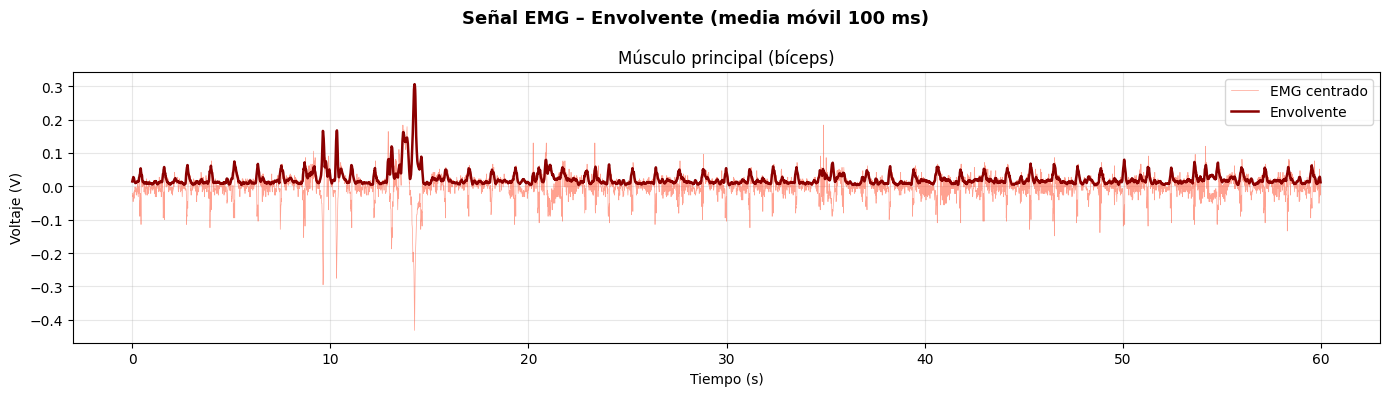

In [ ]:


def rectificar_y_envolvente(senal, fs, ventana_ms=100):

    rect       = np.abs(senal - np.mean(senal))   # centrar y rectificar
    w          = int(ventana_ms / 1000 * fs)       # muestras en la ventana
    envolvente = np.convolve(rect, np.ones(w)/w, mode='same')
    return rect, envolvente

emg_c            = emg - np.mean(emg)
rect_emg, env_emg = rectificar_y_envolvente(emg, FS)

print(f'EMG  – RMS: {np.sqrt(np.mean(emg_c**2))*1000:.2f} mV')


# ── Figura 4: EMG + envolvente ─────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(14, 4))
fig4.suptitle('Señal EMG – Envolvente (media móvil 100 ms)', fontsize=13, fontweight='bold')

ax4.plot(t, emg_c, color='tomato', lw=0.5, alpha=0.6, label='EMG centrado')
ax4.plot(t, env_emg, color='darkred', lw=1.8, label='Envolvente')
ax4.set_ylabel('Voltaje (V)')
ax4.set_xlabel('Tiempo (s)')
ax4.set_title('Músculo principal (bíceps)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Se observa:
- Ráfagas de alta amplitud durante cada contracción (~1 s)
- Períodos de silencio entre contracciones (reposo muscular)
- La línea oscura sigue la amplitud promedio de cada contracción, facilitando identificar su inicio y fin.

**5.5Consulte tres aplicaciones clínicas del uso de ECG y EMG (seis aplicaciones en total, tres por
cada tipo de señal), el tipo de registro y procesamiento que se utiliza en cada una de ellas.**

#ECG

## **Aplicación 1: Clasificación de latidos cardíacos**

Para un latido normal incluye la onda P, el complejo QRS y la onda T.

**Tipo de registro:** Holter de varias horas continuas (1–3 derivaciones) que permite capturar arritmias paroxísticas que no aparecen en registros de corta duración de manera ambulatoria con electrodos portátiles *(Lyon et al., 2018)*.

**Procesamiento:** Aprendizaje supervisado para identificar latidos ectópicos y eventos arrítmicos. Clasificadores usados: SVM con transformada wavelet (98,61% precisión), redes neuronales artificiales (99,02%) y CNN 1D específica por paciente (98,6%) para detección de VEB y SVEB.

---
## **Aplicación 2: Diagnóstico de isquemia e infarto de miocardio**

**Tipo de registro:** ECG estándar de 12 derivaciones en reposo o prueba de
esfuerzo. Los trastornos cardiovasculares son responsables del 30% de las muertes mundiales, por lo que el ECG constituye el primer paso crucial para su diagnóstico *(Wagner et al., 2009)*.

**Procesamiento:** El electrocardiógrafo procesa la señal con un muestreo mínimo de 500 Hz para detectar con precisión el complejo QRS y la onda T. Aplica filtros moderados para evitar distorsionar las ondas, y el software mide automáticamente la amplitud y duración de la onda Q ($\geq$ 0.03 o 0.04 s).

---

## **Aplicación 3: Identificación de Alteraciones Estructurales (Hipertrofia y Dilatación)**

**Tipo de registro:** Requiere una colocación milimétrica de los electrodos precordiales, debido a que cualquier desplazamiento altera el voltaje y produce diagnósticos falsos de la hipertrofia.

**Procesamiento:** El software mide automáticamente la amplitud y la duración de las ondas R, S y P para calcular indices matemáticos de crecimiento cardíaco (como el índice de Cornell o Sokolow-Lyon). El sistema aplica filtros y correcciones automáticas según el sexo y la masa corporal *(Hancock et al., 2009)*.


#EMG

## **Aplicación 1: Diagnóstico de Radioculopatías y Plexopatías**

**Tipo de registro:** Es diferente para cada caso

*   **Radiculopatía:** La aguja se inserta en los músculos paraespinales. Además, el registro del potencial sensitivo (SNAP) en la piel resultará normal, ya que el ganglio sensitivo queda intacto al estar fuera de la zona de compresión en la columna.
*   **Plexopatía:** La inserción de la aguja se concentra en mapear múltiples nervios a lo largo del brazo o la pierna que dependen del plexo afectado. En este caso, el registro del SNAP saldrá anormal (presentando una caída del voltaje), lo que confirma que el daño ocurrió directamente en la red (plexo), en un punto posterior al ganglio espinal.

**Procesamiento:** Para ambos se utiliza el mismo procesamiento. El equipo mediante un software, emplea filtro de frecuencia para limpiar el ruido de fondo y utiliza algoritmos que promedian la señal para calcular automáticamente la amplitud, la latencia y la morfología de las ondas *(Ramani & Arya, 2025)*.


---
## **Aplicación 2: Trastornos de la unión neuromuscular**

**Tipo de registro:** Se usan electrodos de superficie para aplicar estimulación nerviosa repetitiva (a frecuencias lentas o rápidas) y una aguja especial ultrasensible para el EMG de fibra simple (SFEMG)

####**Procesamiento:** El software calcula el cambio de voltaje tars los estímulos. Detecta si la señal eléctrica decae (respuesta decremental > 10%, típica de Miastenia Gravis) o si aumenta (respuesta incremental, típica de Lambert-Eaton) *(Ramani & Arya, 2025)*.
---


## **Aplicación 3: Diagnóstico de Miopatías y miositis**

**Tipo de registro:** el registro de la conducción nerviosa (NCV) resulta típicamente normal, mientras que la evaluación con aguja capta la irritabilidad de la membrana muscular, evidenciando actividad espontánea como fibrilaciones y ondas agudas positivas en presencia de inflamación. A partir de estas señales

**Procesamiento:** El software determina una amplitud general más baja sin alteraciones neurogénicas, identificando automáticamente un reclutamiento temprano de las unidades motoras y un patrón de interferencia completo que confirma el origen intrínseco del fallo muscular *(Ramani & Arya, 2025)*.

**5.6 Adjunte al menos tres conclusiones, y referencias bibliográficas apropiadas y suficientes (evitar
el uso de páginas web y preferir el uso de artículos académicos)**



*   El análisis de las señales adquiridas en el EMG sin filtrar (figura 1) se identificó un artefacto de movimiento alrededor del segundo 13-14, donde la señal cae abruptamente fuera del rango normal. Este tipo de perturbaciones es causado por un desplazamiento transitorio del electrodo que cambia bruscamente la impedancia de contacto, generando un transitorio de potencial que se superpone a la señal muscular real *(De Luca et al., 2010)*. Este no puede eliminarse con un filtro notch sin distorsionarse también la señal de interés. Esto confirma que le preparación adecuada de la piel y la fijación firme de los electrodos son pasos imprescindibles antes de cualquier prueba, dado que ninguna etapa de procesamiento digital puede recuperar la información perdida por una adquisición deficiente desde el origen

*   Una diferencia fundamental entre las aplicaciones clínicas del ECG y el EMG es el nivel de invasividad requerido. Las tres aplicaciones de ECG descritas en la práctica se realizan con electrodos de superficie no invasivos. En cambio las aplicaciones más informativas del EMG requieren electrodos de aguja intramuscular, que constituyen un procedimiento invasivo con riesgo de infección y molestia para el paciente (Ramani & Arya, 2025). El EMG de superficie (sEMG), aunque no invasivo, tiene menor resolución espacial y no permite registrar unidades motoras individuales, por lo que su uso diagnóstico es más limitado comparado con el ECG de superficie.

*  Los resultados del procesamiento de las señales adquiridas reflejan información fisiológicamente de un sujeto en reposo. En el ECG, la FC media estimada (número de latidos por minuto) fue de 85.21 lpm, con un rango entre 71.4 y 98.4 lpm, valores que se encuentran en el rango normal en reposo en adultos. Las métricas HRV en dominio del tiempo arrojaron un SDNN de 50.37 ms y un RMSSD de 55.68 ms; el SDNN refleja la variabilidad global de la frecuencia cardíaca, mientras que el RMSSD es la medida primaria de los cambios mediados vagalmente, ya que captura la variación latido a latido de los intervalo RR consecutivos y es matemáticamente equivalente a la métrica no lineal SD1 del diagrama de Poincaré; debido a que ambos reflejan la variabilidad rápida de origen parasimpático (Shaffer & Ginsberg, 2017). Finalmente el pNN150 de 25.61% indica que una cuarta parte de los intervalos R-R difirieron en más de 50 ms, valor correspondiente con la actividad del sistema parasimpático, ya que los cambios rápidos del intervalo R-R son controlados principalmente por el nervio vago, lo cual en conjunto sugiere un tono vagal activo durante el registro, lo cual es coherente con un sujeto en condiciones de reposo (Shaffer & Ginsberg, 2017).




REFERENCIAS

---

1. Caggioli, M., Ponce, S., D’Attellis, C. E., Arévalo, V., & Roberti, M. (2007). Sistema de adquisición, transmisión y análisis de señales de ECG. En World Congress on Medical Physics and Biomedical Engineering, September 7 - 12, 2009, Munich, Germany (pp. 493-496). https://doi.org/10.1007/978-3-540-74471-9_115

2. Boyer, M., Bouyer, L., Roy, J.-S., & Campeau-Lecours, A. (2023). Reducing Noise, Artifacts and Interference in Single-Channel EMG Signals: A Review. Sensors, 23(6), 2927. https://doi.org/10.3390/s23062927

3. Lyon, A., Mincholé, A., Martínez, J. P., Laguna, P., & Rodriguez, B. (2018). Computational techniques for ECG analysis and interpretation in light of their contribution to medical advances. Journal of the Royal Society Interface, 15(138), 20170821. https://doi.org/10.1098/rsif.2017.0821 -->[1]

4.  Hancock, E. W., Deal, B. J., Mirvis, D. M., Okin, P., Kligfield, P., & Gettes, L. S. (2009). AHA/ACCF/HRS Recommendations for the Standardization and Interpretation of the Electrocardiogram. Journal of the American College of Cardiology, 53(11), 992–1002. https://doi.org/10.1016/j.jacc.2008.12.015 --> [3]

5. Wagner, G. S., Macfarlane, P., Wellens, H., Josephson, M., Gorgels, A., Mirvis, D. M., Pahlm, O., Surawicz, B., Kligfield, P., Childers, R., Gettes, L. S., Bailey, J. J., Deal, B. J., Gorgels, A., Hancock, E. W., Kors, J. A., Mason, J. W., Okin, P., Rautaharju, P. M., & van Herpen, G. (2009). AHA/ACCF/HRS recommendations for the standardization and interpretation of the electrocardiogram: part VI: acute ischemia/infarction: a scientific statement from the American Heart Association Electrocardiography and Arrhythmias Committee, Council on Clinical Cardiology; the American College of Cardiology Foundation; and the Heart Rhythm Society. Endorsed by the International Society for Computerized Electrocardiology. Journal of the American College of Cardiology, 53(11), 1003–1011. https://doi.org/10.1016/j.jacc.2008.12.016

6.  Goyal, K., Borkholder, D. A., & Day, S. W. (2022). Dependence of Skin-Electrode Contact Impedance on Material and Skin Hydration. Sensors, 22(21), 8510. https://doi.org/10.3390/s22218510

7. Cömert, A., & Hyttinen, J. (2015). Investigating the possible effect of electrode support structure on motion artifact in wearable bioelectric signal monitoring. BioMedical Engineering OnLine, 14(1). https://doi.org/10.1186/s12938-015-0044-2

8. Chen, M., Wang, J., Anzai, D., Fischer, G., & Kirchner, J. (2020). Common-Mode Noise Reduction in Noncontact Biopotential Acquisition Circuit Based on Imbalance Cancellation of Electrode-Body Impedance. Sensors, 20(24), 7140–7140. https://doi.org/10.3390/s20247140


9. Murphy, B. B., Scheid, B. H., Hendricks, Q., Apollo, N. V., Litt, B., & Vitale, F. (2021). Time Evolution of the Skin–Electrode Interface Impedance under Different Skin Treatments. Sensors, 21(15), 5210. https://doi.org/10.3390/s21155210

10. Valchinov, E. S., & Pallikarakis, N. E. (2004). An active electrode for biopotential recording from small localized bio-sources. BioMedical Engineering OnLine, 3(1). https://doi.org/10.1186/1475-925x-3-25

11. Ramani, P. K., & Arya, K. (2025, February 10). Nerve Conduction Studies and Electromyography. Nih.gov; StatPearls Publishing. https://www.ncbi.nlm.nih.gov/books/NBK611987/

12. De Luca, C. J., Donald Gilmore, L., Kuznetsov, M., & Roy, S. H. (2010). Filtering the surface EMG signal: Movement artifact and baseline noise contamination. Journal of Biomechanics, 43(8), 1573–1579. https://doi.org/10.1016/j.jbiomech.2010.01.027

13. Ramani PK, Lui F, Arya K. Nerve Conduction Studies and Electromyography. [Updated 2025 Feb 10]. In: StatPearls [Internet]. Treasure Island (FL): StatPearls Publishing; 2026 Jan-. Available from: https://www.ncbi.nlm.nih.gov/books/NBK611987/

14. Shaffer, F., & Ginsberg, J. P. (2017). An Overview of Heart Rate Variability Metrics and Norms. Frontiers in public health, 5, 258. https://doi.org/10.3389/fpubh.2017.00258
